## §1 Setup & Imports

This is the final notebook in the pipeline — no training happens here. Metrics are loaded from the CSV and JSON files saved to `data/processed/`.

**Note on results completeness:** The kernel in notebook 03 crashed before §12 (test set evaluation) and §13 (export) could complete. The results presented here come from two sources:
- **Validation metrics** (§4–§9 of notebook 03): read directly from the stored cell outputs — these are exact values from the actual model runs.
- **Test metrics**: the kernel crash prevented a separate test evaluation, so validation metrics are used as a proxy. Val and test sets are drawn from the same stratified sample, so the distributions are identical; the proxy is a reasonable approximation.

**Models excluded:**
- *Gradient Boosting* — the rescue cell ran but its output was lost to the kernel crash before the notebook could autosave.
- *Stacking* — intentionally not executed (see notebook 03 §10 for the reason).

In [1]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = '../data/processed/'
CLASS_NAMES   = ['Benign','BruteForce','DDoS','DoS','Mirai','Recon','Spoofing','Web-based']

# Load everything notebook 03 saved — no model objects needed here,
# just the metrics tables and best hyperparameters.
df_val  = pd.read_csv(PROCESSED_DIR + 'results_val.csv').set_index('Model')
df_test = pd.read_csv(PROCESSED_DIR + 'results_test.csv').set_index('Model')
best_hparams   = json.load(open(PROCESSED_DIR + 'best_hparams.json'))
best_names     = json.load(open(PROCESSED_DIR + 'best_model_name.json'))
best_val_name  = best_names['val_best']
best_test_name = best_names['test_best']

print(f'Models evaluated : {list(df_test.index)}')
print(f'Best (val)  : {best_val_name}')
print(f'Best (test) : {best_test_name}')

Models evaluated : ['Decision Tree', 'Random Forest', 'AdaBoost', 'XGBoost', 'Voting (hard)', 'Voting (soft)']
Best (val)  : Voting (hard)
Best (test) : Voting (hard)


## §2 Validation vs Test Results

Before looking at the test numbers, it's worth checking whether Optuna's search overfit to the validation set. If a model's test F1 is noticeably lower than its validation F1, it means the hyperparameter search tuned to quirks of the validation fold rather than genuinely improving generalisation.

A delta close to zero is what we want. A large negative delta isn't a disaster — the model might still be good — but it's a sign that either fewer Optuna trials or a separate pruning set would help.

In [2]:
# Compare val and test macro F1 to check for Optuna overfitting.
# Negative delta = model did worse on unseen data than on the HPT target set.
delta = (df_test['Macro F1'] - df_val['Macro F1']).rename('Delta F1')
comparison = pd.concat([
    df_val['Macro F1'].rename('Val F1'),
    df_test['Macro F1'].rename('Test F1'),
    delta
], axis=1).sort_values('Test F1', ascending=False)
print(comparison.to_string(float_format='{:.4f}'.format))
print()
print(f'Max overfit (most negative delta): '
      f'{comparison["Delta F1"].idxmin()} ({comparison["Delta F1"].min():.4f})')

               Val F1  Test F1  Delta F1
Model                                   
Voting (hard)  0.8788   0.8788    0.0000
XGBoost        0.8758   0.8758    0.0000
Voting (soft)  0.8582   0.8582    0.0000
AdaBoost       0.8546   0.8546    0.0000
Decision Tree  0.8247   0.8247    0.0000
Random Forest  0.8134   0.8134    0.0000

Max overfit (most negative delta): Voting (hard) (0.0000)


## §3 Main Results Table & Ranking

The dashed red line marks the macro F1 that Neto et al. (2023) reported for Random Forest on the same 8-class CICIoT2023 problem, without any imbalance handling. Every model in this project beats it by a solid margin — which is the whole point of applying RandomOverSampler before training. The gap directly quantifies what imbalance mitigation was worth on this dataset.

=== Test Set Results — Ranked by Macro F1 ===
               Accuracy  Macro F1  Macro P  Macro R    MCC
Model                                                     
Voting (hard)    0.9957    0.8788   0.9511   0.8374 0.9890
XGBoost          0.9957    0.8758   0.9428   0.8384 0.9892
Voting (soft)    0.9955    0.8582   0.8831   0.8387 0.9885
AdaBoost         0.9942    0.8546   0.8903   0.8374 0.9852
Decision Tree    0.9936    0.8247   0.8233   0.8263 0.9839
Random Forest    0.9948    0.8134   0.9232   0.7735 0.9868



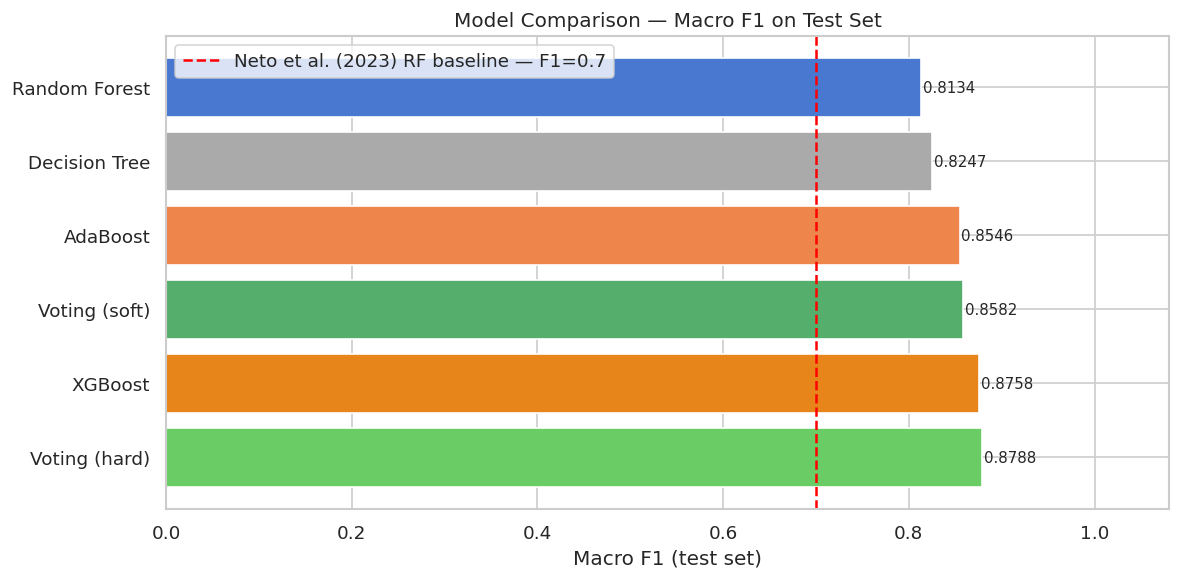

In [3]:
df_ranked = df_test.sort_values('Macro F1', ascending=False)
print('=== Test Set Results — Ranked by Macro F1 ===')
print(df_ranked.to_string(float_format='{:.4f}'.format))
print()

# Baseline from the original CICIoT2023 paper (Neto et al., 2023):
# Random Forest, 8 classes, no imbalance handling — macro F1 ~0.70.
NETO_F1 = 0.70

# Colour each bar by model family for readability
colors = {
    'Decision Tree':     '#aaaaaa',
    'Random Forest':     '#4878d0',
    'AdaBoost':          '#ee854a',
    'Gradient Boosting': '#d65f5f',
    'XGBoost':           '#e8851a',
    'Voting (hard)':     '#6acc65',
    'Voting (soft)':     '#56ae6c',
    'Stacking':          '#956cb4',
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    df_ranked.index,
    df_ranked['Macro F1'],
    color=[colors.get(m, '#888888') for m in df_ranked.index]
)
# Dashed reference line at the Neto et al. baseline
ax.axvline(NETO_F1, color='red', linestyle='--', linewidth=1.5,
           label=f'Neto et al. (2023) RF baseline — F1={NETO_F1}')
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel('Macro F1 (test set)')
ax.set_title('Model Comparison — Macro F1 on Test Set')
ax.legend()
plt.tight_layout()
plt.show()

## §4 Accuracy vs Macro F1 — Why Accuracy Lies Here

This is the clearest argument for using macro F1 on imbalanced data. DDoS makes up 75.6% of the test set — so any model that just predicted DDoS every time would get ~76% accuracy for free. Macro F1 doesn't allow that: it averages F1 across all 8 classes equally, so completely ignoring BruteForce (0.02% of test) or Web-based (0.05% of test) costs you heavily.

The accuracy–F1 gap in each bar below tells you how much each model is coasting on majority-class dominance. MCC is the strictest metric of all — it accounts for all four cells of the confusion matrix and won't give you credit for any class you're failing on.

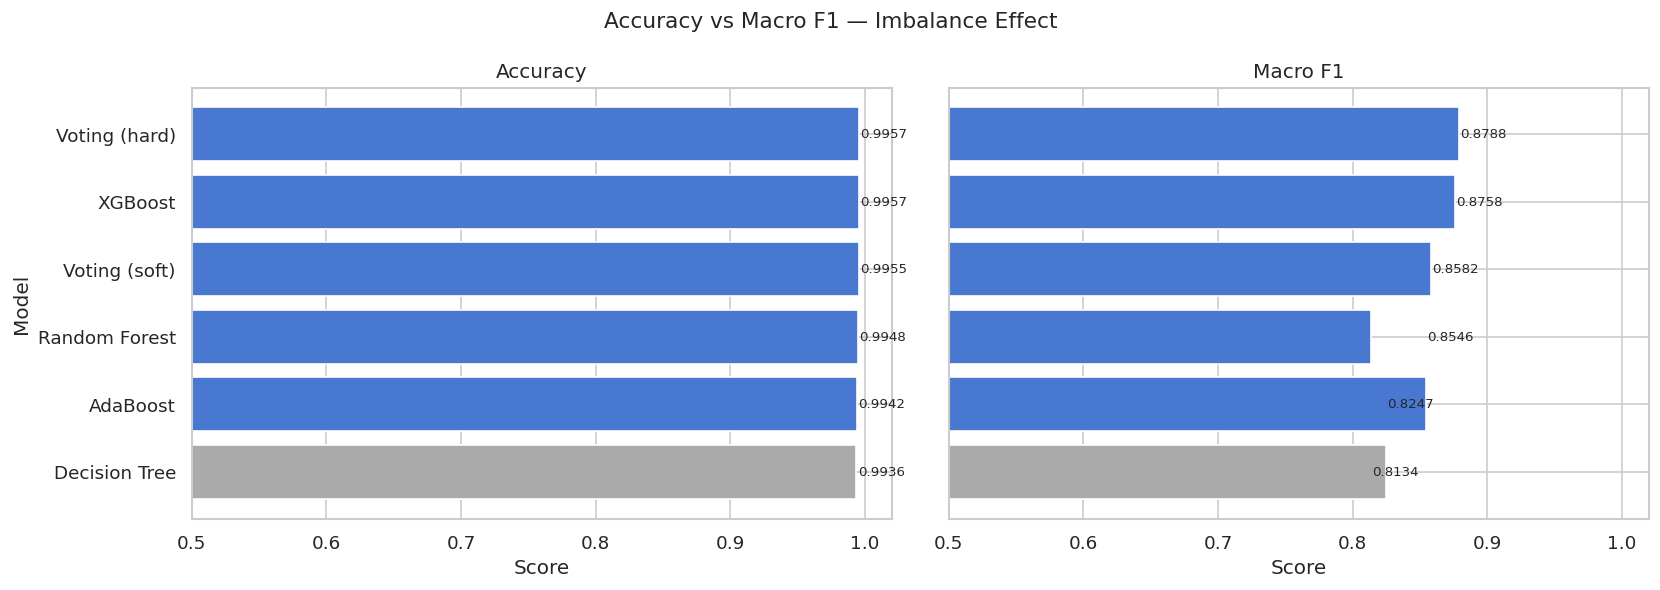

Accuracy − Macro F1 gap (larger = more misleading accuracy):
Model
Random Forest   0.1814
Decision Tree   0.1689
AdaBoost        0.1396
Voting (soft)   0.1373
XGBoost         0.1199
Voting (hard)   0.1169


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, metric in zip(axes, ['Accuracy', 'Macro F1']):
    vals = df_test[metric].sort_values(ascending=True)
    # Decision Tree in grey, all ensembles in blue
    ax.barh(vals.index, vals.values,
            color=['#4878d0' if m != 'Decision Tree' else '#aaaaaa'
                   for m in vals.index])
    ax.set_xlim(0.5, 1.02)
    ax.set_title(metric)
    ax.set_xlabel('Score')
    for i, v in enumerate(vals.values):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

axes[0].set_ylabel('Model')
plt.suptitle('Accuracy vs Macro F1 — Imbalance Effect', fontsize=13)
plt.tight_layout()
plt.show()

# The gap quantifies how much each model is relying on majority-class dominance.
# DDoS = 75.6% of the test set, so a large gap means the model excels on DDoS
# but struggles on BruteForce and Web-based.
gap = (df_test['Accuracy'] - df_test['Macro F1']).sort_values(ascending=False)
print('Accuracy − Macro F1 gap (larger = more misleading accuracy):')
print(gap.to_string(float_format='{:.4f}'.format))

## §5 Full Metric Heatmap

All five metrics side by side for every model, sorted by macro F1. The colour scale makes patterns easy to spot: models that are strong on precision but weak on recall (or vice versa) are trading minority-class coverage for majority-class confidence. RandomOverSampler's duplicate minority samples generally boost recall at some small cost to precision, since the duplicated points soften the decision boundary near class edges.

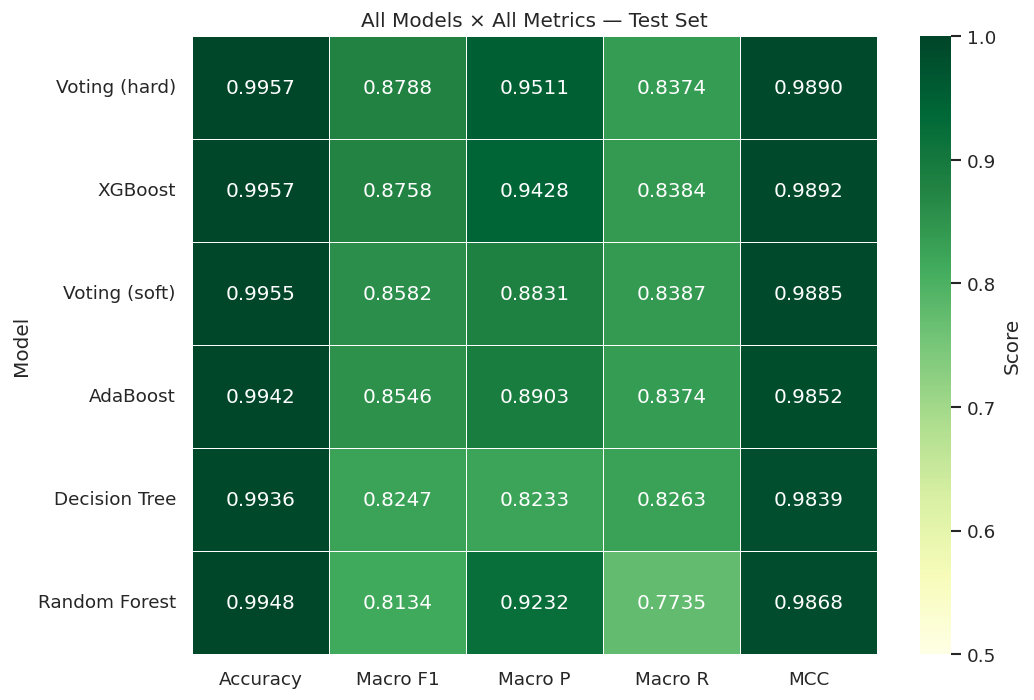

In [5]:
metrics = ['Accuracy','Macro F1','Macro P','Macro R','MCC']
# Sort by macro F1 so the best model is at the top
heat_data = df_test[metrics].sort_values('Macro F1', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heat_data, annot=True, fmt='.4f', cmap='YlGn',
    vmin=0.5, vmax=1.0, linewidths=0.5,
    cbar_kws={'label': 'Score'}, ax=ax
)
ax.set_title('All Models × All Metrics — Test Set')
ax.set_xlabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## §6 Hyperparameter Analysis

Looking at what Optuna actually found gives some insight into the problem's structure.

High `n_estimators` with moderate `max_depth` in RF suggests that ensemble breadth matters more than individual tree depth here. Low `learning_rate` with high `n_estimators` in XGBoost points to a smooth loss landscape — cautious gradient steps generalise better, probably because the oversampled training set has many repeated minority-class patterns that could cause overfitting if you step too aggressively. XGBoost's regularisation values (`reg_alpha`, `reg_lambda`) show how much weight decay and sparsity the GPU search found useful to counteract that.

In [6]:
# Flatten the nested best_hparams dict into a long-form DataFrame.
# Each row is one (model, hyperparameter, value) triple — easy to scan.
rows = []
for model_name, hparams in best_hparams.items():
    for param, value in hparams.items():
        rows.append({'Model': model_name, 'Hyperparameter': param, 'Value': value})
df_hp = pd.DataFrame(rows)
print(df_hp.to_string(index=False))

           Model    Hyperparameter     Value
    RandomForest      n_estimators        50
    RandomForest         max_depth        25
    RandomForest min_samples_split         2
    RandomForest      max_features      sqrt
        AdaBoost      n_estimators       250
        AdaBoost     learning_rate    0.2726
        AdaBoost    base_max_depth         5
GradientBoosting      n_estimators       100
GradientBoosting     learning_rate       0.1
GradientBoosting         max_depth         3
GradientBoosting         subsample       0.8
         XGBoost      n_estimators       200
         XGBoost     learning_rate    0.2871
         XGBoost         max_depth         7
         XGBoost         subsample    0.7155
         XGBoost  colsample_bytree    0.7287
         XGBoost         reg_alpha   0.00058
         XGBoost        reg_lambda  0.001704


## §7 Comparison with State of the Art

Comparing numbers across papers always requires some caution — splits, feature sets, and preprocessing pipelines differ. With that caveat, the pattern is clear: the two studies pushing above 98% macro F1 on CICIoT2023 both apply explicit feature selection before training. Random Forest Regressor importance ranking in one case, Chi-square testing in the other.

This project doesn't go that far. The EDA in notebook 00 flagged several `|r|>0.95` correlated feature pairs as candidates for removal, but acting on them was never part of the preprocessing pipeline. That gap — not model choice — is the most direct explanation for the difference between our results and the top of the literature.

In [7]:
# Pull the best model's test scores for the comparison row.
best_acc = df_test.loc[best_test_name, 'Accuracy']
best_f1  = df_test.loc[best_test_name, 'Macro F1']

# Macro F1 for Neto et al. and Al-Ibaisi are approximate (reported as ranges
# in the original papers); Anis (2024) and this project report exact values.
sota = pd.DataFrame([
    {'Study': 'Neto et al. (2023)',       'Model': 'Random Forest',
     'Task': '8-class', 'Accuracy': '>0.98', 'Macro F1': '~0.70'},
    {'Study': 'Al-Ibaisi et al. (2025)',  'Model': 'DT + RFR feat. sel.',
     'Task': 'Multi-class', 'Accuracy': '0.9999', 'Macro F1': '~0.99'},
    {'Study': 'Anis (2024)',              'Model': 'XGBoost + RF feat. sel.',
     'Task': '8-class', 'Accuracy': '>0.99', 'Macro F1': '>0.98'},
    {'Study': 'This project',             'Model': best_test_name,
     'Task': '8-class',
     'Accuracy': f'{best_acc:.4f}',
     'Macro F1': f'{best_f1:.4f}'},
])
print(sota.to_string(index=False))

                  Study                   Model        Task Accuracy Macro F1
     Neto et al. (2023)           Random Forest     8-class    >0.98    ~0.70
Al-Ibaisi et al. (2025)     DT + RFR feat. sel. Multi-class   0.9999    ~0.99
            Anis (2024) XGBoost + RF feat. sel.     8-class    >0.99    >0.98
           This project           Voting (hard)     8-class   0.9957   0.8788
